Imports

In [381]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

Load data

In [382]:
df = pd.read_csv("data/un-general-debates.csv")
print(df.shape)

(7507, 4)


In [383]:
print("Columns:     ", df.columns.tolist())
print("Year range:    ", df['year'].min(), '-' , df['year'].max())
print("Unique countries:    ", df['country'].nunique())
print("Missing Values: ", df.isnull().sum())
print("Countries (iso3): ", sorted(df['country'].unique()))

Columns:      ['session', 'year', 'country', 'text']
Year range:     1970 - 2015
Unique countries:     199
Missing Values:  session    0
year       0
country    0
text       0
dtype: int64
Countries (iso3):  ['AFG', 'AGO', 'ALB', 'AND', 'ARE', 'ARG', 'ARM', 'ATG', 'AUS', 'AUT', 'AZE', 'BDI', 'BEL', 'BEN', 'BFA', 'BGD', 'BGR', 'BHR', 'BHS', 'BIH', 'BLR', 'BLZ', 'BOL', 'BRA', 'BRB', 'BRN', 'BTN', 'BWA', 'CAF', 'CAN', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COD', 'COG', 'COL', 'COM', 'CPV', 'CRI', 'CSK', 'CUB', 'CYP', 'CZE', 'DDR', 'DEU', 'DJI', 'DMA', 'DNK', 'DOM', 'DZA', 'ECU', 'EGY', 'ERI', 'ESP', 'EST', 'ETH', 'EU', 'FIN', 'FJI', 'FRA', 'FSM', 'GAB', 'GBR', 'GEO', 'GHA', 'GIN', 'GMB', 'GNB', 'GNQ', 'GRC', 'GRD', 'GTM', 'GUY', 'HND', 'HRV', 'HTI', 'HUN', 'IDN', 'IND', 'IRL', 'IRN', 'IRQ', 'ISL', 'ISR', 'ITA', 'JAM', 'JOR', 'JPN', 'KAZ', 'KEN', 'KGZ', 'KHM', 'KIR', 'KNA', 'KOR', 'KWT', 'LAO', 'LBN', 'LBR', 'LBY', 'LCA', 'LIE', 'LKA', 'LSO', 'LTU', 'LUX', 'LVA', 'MAR', 'MCO', 'MDA', 'MDG', '

In [384]:
df['word_count'] = df['text'].str.split().str.len()
df['char_count'] = df['text'].str.len() 
df['decade'] = (df['year'] // 10 * 10).astype(str) + 's'


Temporal Coverage

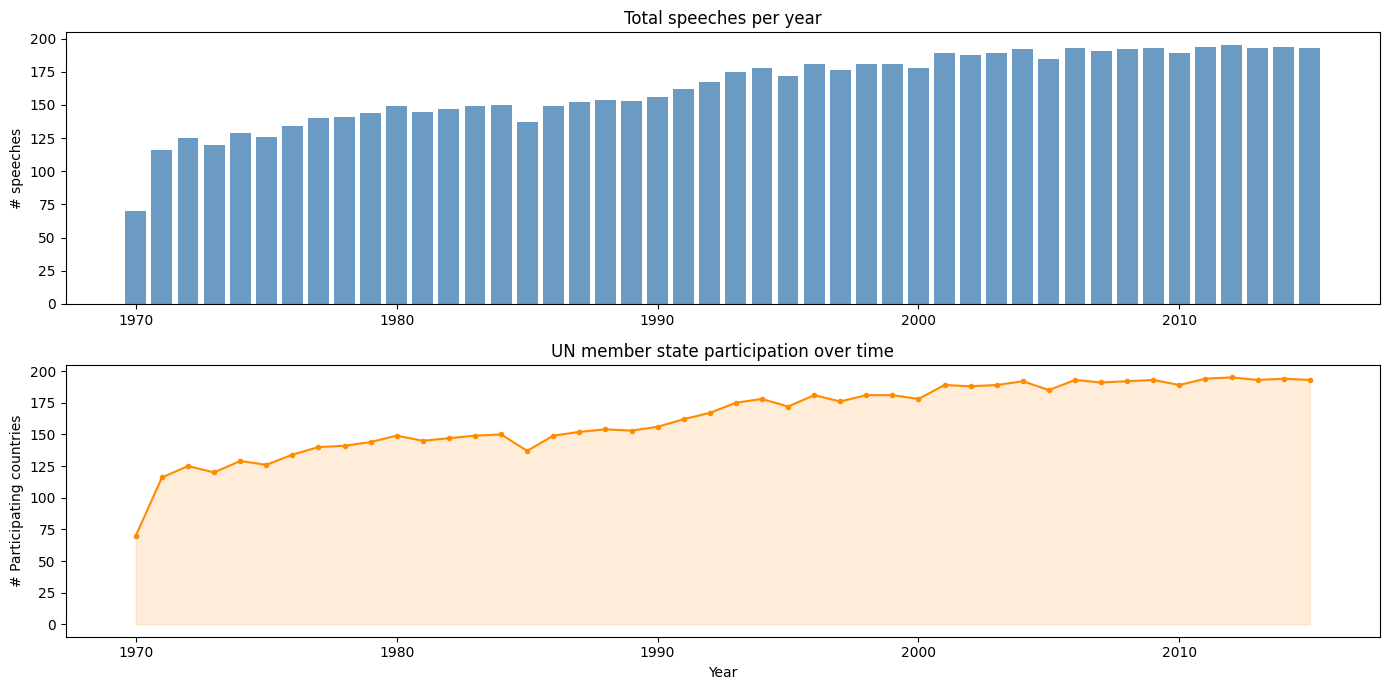

In [385]:
speeches_per_year = df.groupby('year').size()
countries_per_year = df.groupby('year')['country'].nunique()


fig, axes = plt.subplots(2, 1, figsize=(14,7), sharex=True)
axes[0].bar(speeches_per_year.index, speeches_per_year.values, color='steelblue', alpha=0.8)
axes[0].set_ylabel('# speeches')
axes[0].set_title('Total speeches per year')
axes[0].tick_params(labelbottom=True) 

axes[1].plot(countries_per_year.index, countries_per_year.values, marker='o', markersize=3, color='darkorange', linewidth=1.5)
axes[1].fill_between(countries_per_year.index, countries_per_year.values, alpha=0.15, color='darkorange')
axes[1].set_ylabel('# Participating countries')
axes[1].set_xlabel('Year')
axes[1].set_title('UN member state participation over time')

plt.tight_layout()
plt.show()



Speech Length Analysis

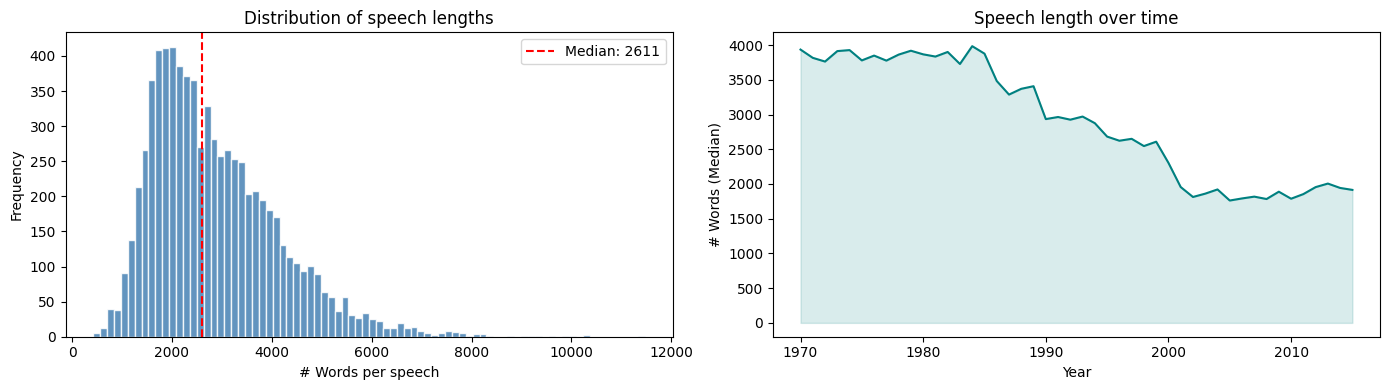

In [386]:
# --Distribution of speech lengths
fig,axes = plt.subplots(1,2,figsize=(14,4))
axes[0].hist(df['word_count'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['word_count'].median(), color='red', linestyle='--',label=f"Median: {df['word_count'].median():.0f}")
axes[0].set_xlabel("# Words per speech")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of speech lengths")
axes[0].legend()

# --Median word count per year
median_wc = df.groupby('year')['word_count'].median()
axes[1].plot(median_wc.index, median_wc.values, color='teal', linewidth=1.5)
axes[1].fill_between(median_wc.index, median_wc.values, alpha=0.15, color='teal')
axes[1].set_xlabel("Year")
axes[1].set_ylabel("# Words (Median)")
axes[1].set_title("Speech length over time")
plt.tight_layout()
plt.show()
#print(df['word_count'].describe().round(1))

C:\Users\Nico\AppData\Local\Temp\ipykernel_9796\3579932898.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


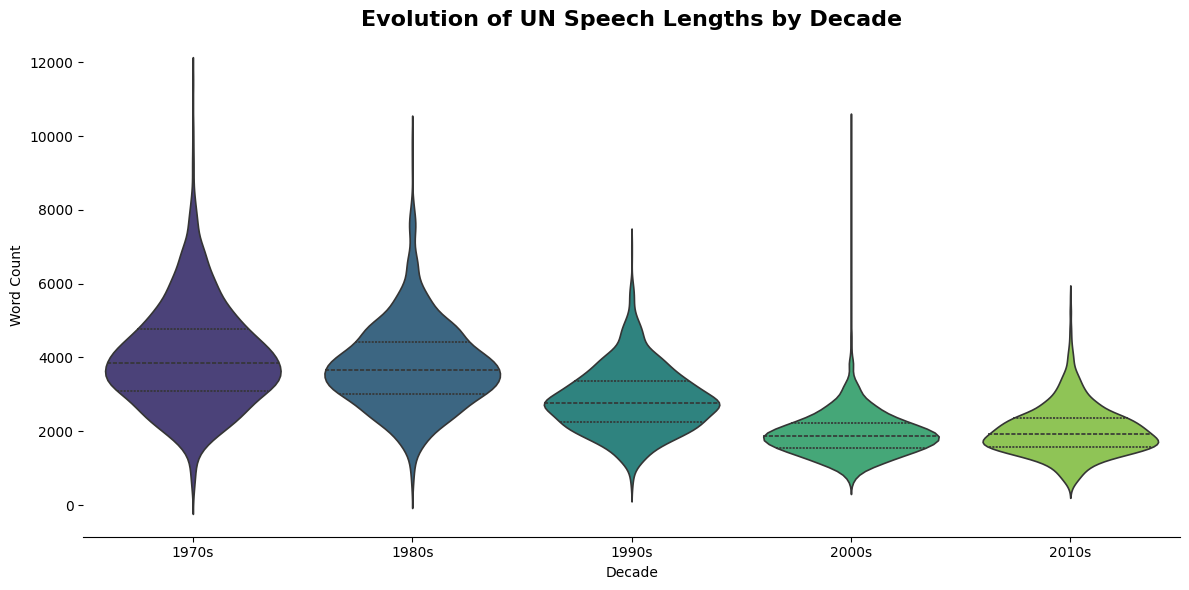

In [387]:

plt.figure(figsize=(12, 6))

ax = sns.violinplot(
    data=df, 
    x='decade', 
    y='word_count', 
    order=sorted(df['decade'].unique()),
    palette="viridis",
    inner="quartile", 
    linewidth=1.2
)

ax.set_title("Evolution of UN Speech Lengths by Decade", fontsize=16, fontweight='bold')
ax.set_xlabel("Decade")
ax.set_ylabel("Word Count")

sns.despine(left=True)

plt.tight_layout()
plt.show()

Most Used Words

In [388]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nico\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Nico\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Nico\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

C:\Users\Nico\AppData\Local\Temp\ipykernel_9796\3478521443.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df,


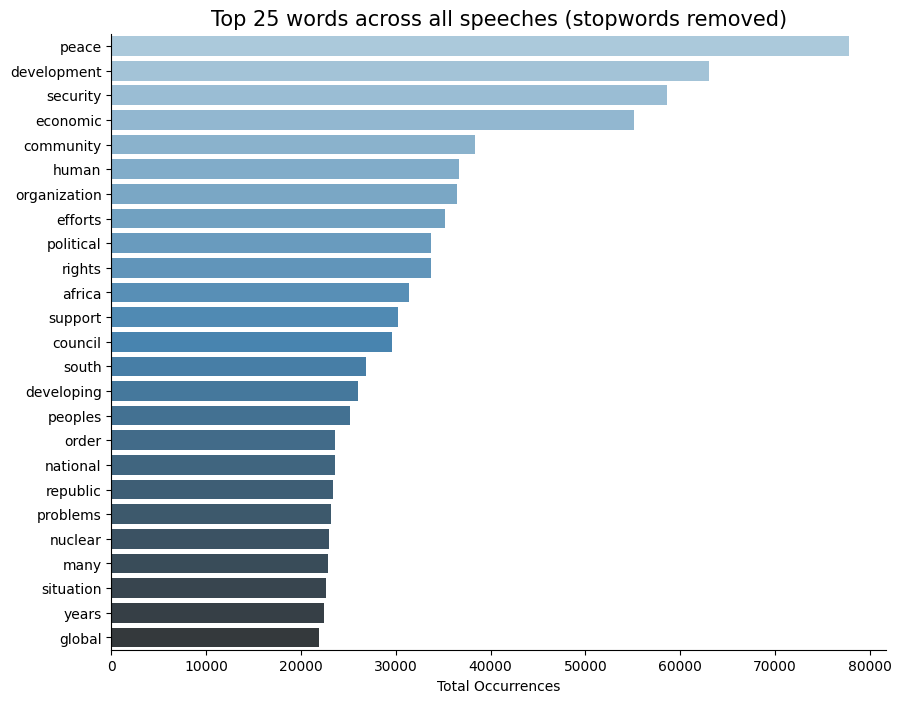

In [389]:

STOP_WORDS = set(stopwords.words('english')) 
# UN-specific words that are not interesting. Can be extended.
EXTRA_STOP = {'mr','president','assembly', 'general', 'nations', 'united', 'also', 'must', 'would', 'may', 'upon', 'one', 'us', 'said', 'delegation', 'statement', 'session', 'country', 'countries','government','international', 'world', 'people','new', 'year','charter', 'secretary', 'sir', 'like', 'first', 'time', 'shall', 'states', 'state' }

def tokenize(txt):
    tokens = re.findall(r'\b[a-z]{3,}\b', txt.lower())
    return [t for t in tokens if t not in STOP_WORDS | EXTRA_STOP]

df['tokens'] = df['text'].apply(tokenize)


# Top 25 most occuring words (ever)
top_25_df = df['tokens'].explode().value_counts().head(25).reset_index()
top_25_df.columns = ['word', 'count']
plt.figure(figsize=(10, 8))
sns.barplot(data=top_25_df,
            y='word',
            x='count',
            palette='Blues_d')

sns.despine()
plt.title("Top 25 words across all speeches (stopwords removed)", fontsize=15)
plt.xlabel("Total Occurrences")
plt.ylabel("")
plt.show()

c:\Users\Nico\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


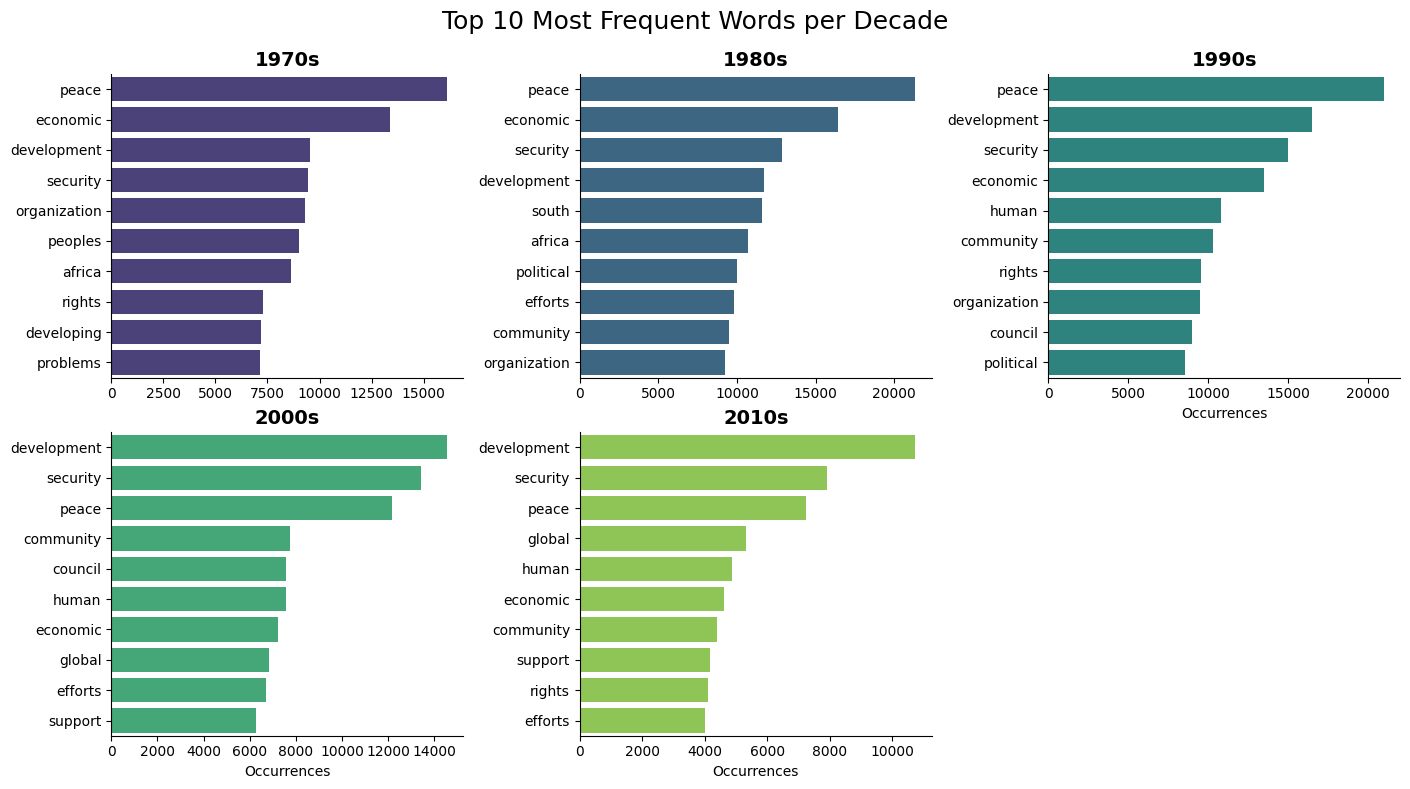

In [390]:

top_10_by_decade = (df.explode('tokens')
                    .groupby(['decade', 'tokens'])
                    .size()
                    .reset_index(name='count')
                    .sort_values(['decade', 'count'], ascending=[True, False])
                    .groupby('decade')
                    .head(10))

g = sns.FacetGrid(top_10_by_decade, 
                  col="decade",
                  col_wrap=3,
                  sharex=False,
                  sharey=False,
                  height=4,
                  aspect=1.2,
                  hue="decade",
                  palette="viridis")

g.map(sns.barplot, "count", "tokens")

g.set_titles("{col_name}", size=14, fontweight='bold')
g.set_axis_labels("Occurrences", "")
plt.subplots_adjust(top=0.9)
g.figure.suptitle("Top 10 Most Frequent Words per Decade", fontsize=18)
plt.show()    


Keyword Tracking Over Time

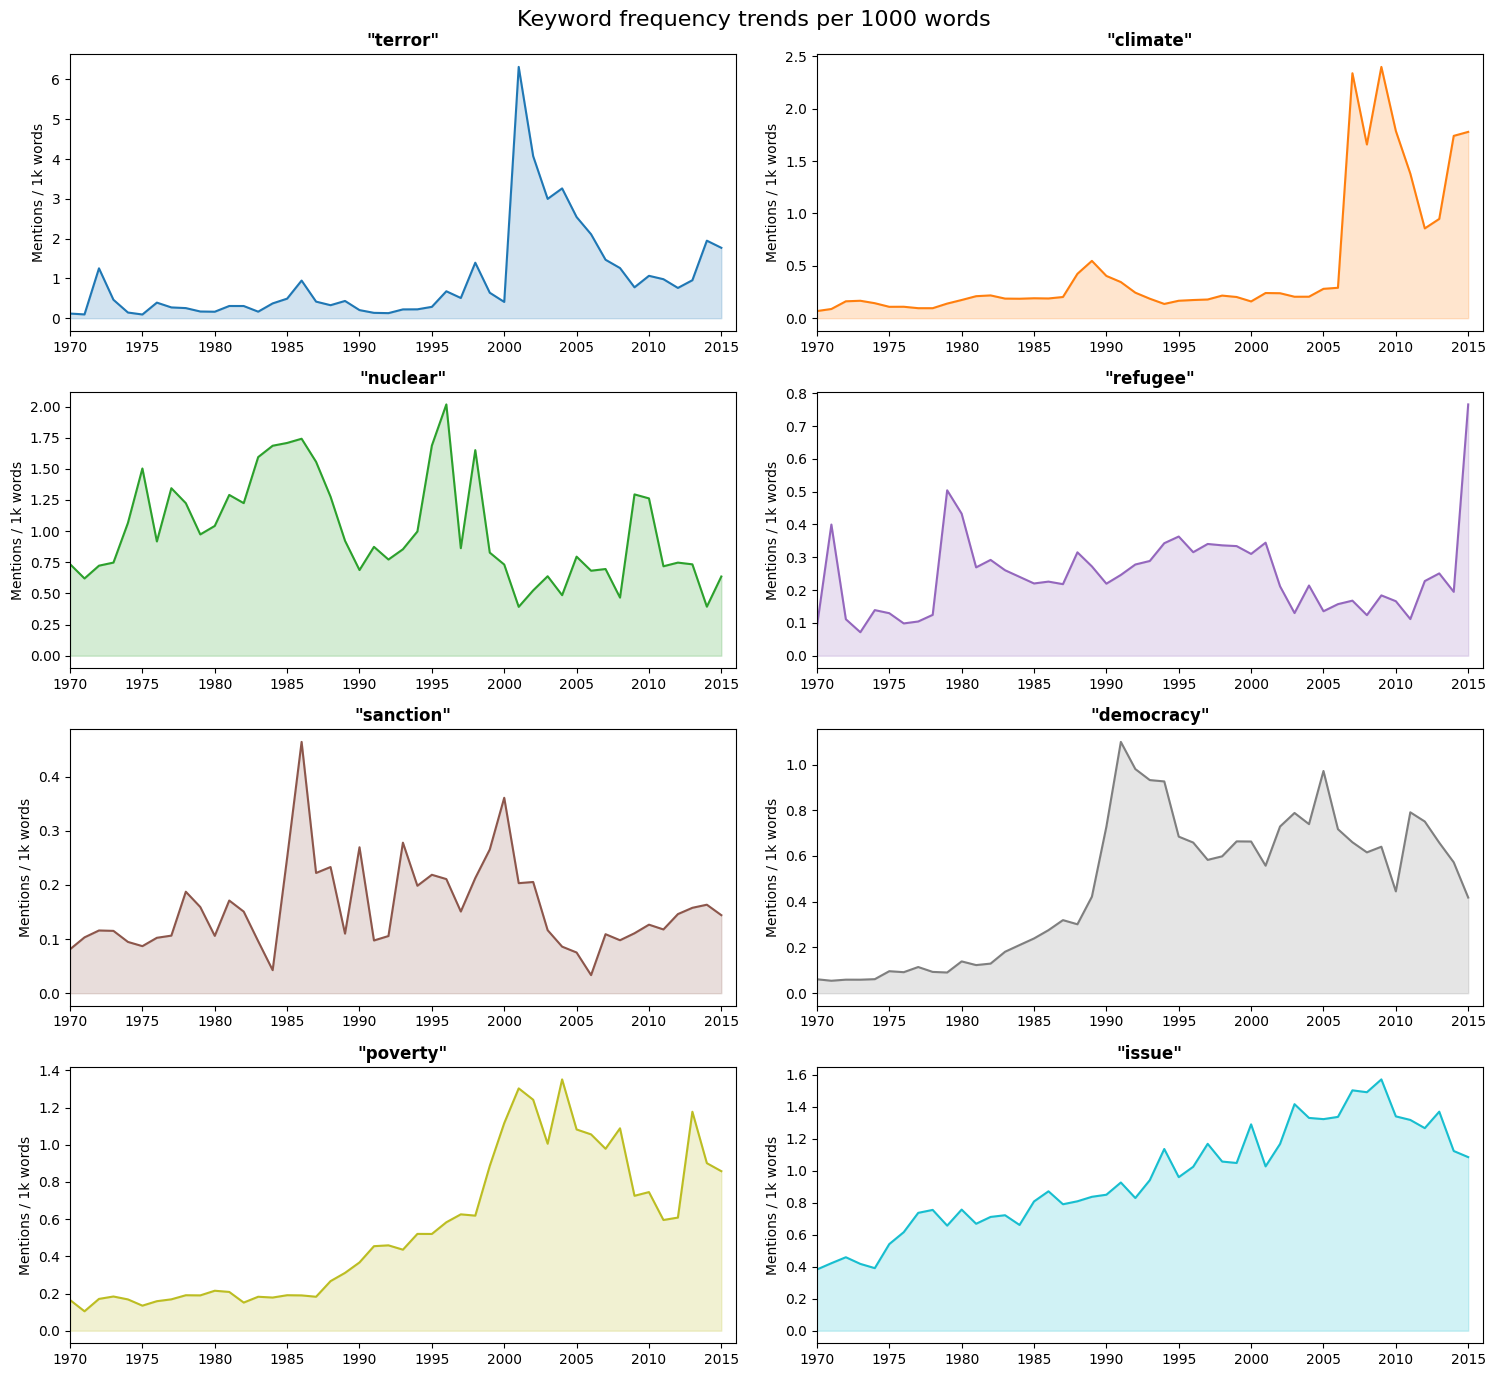

In [ ]:
# --Keywords Frequency Trends
sns.reset_defaults()

keywords = ['terror', 'climate', 'nuclear', 'refugee', 'sanction', 'democracy', 'poverty', 'issue']
def k_freq_per_year(keyword):
    pattern = rf'\b{keyword}\w*\b'  # stem match, e.g. 'issue' matches 'issues'
    df['_kw_count'] = df['text'].str.lower().str.count(pattern)
    df['_kw_norm']  = df['_kw_count'] / (df['word_count'] / 1000)
    return df.groupby('year')['_kw_norm'].mean()

kw_series = {kw: k_freq_per_year(kw) for kw in keywords}

fig, axes = plt.subplots(4, 2, figsize=(15, 14), sharex=False)
axes = axes.flatten()
colors = plt.cm.tab10(np.linspace(0, 1, len(keywords)))


for i, (kw, series) in enumerate(kw_series.items()):
    axes[i].plot(series.index, series.values, linewidth=1.5, color=colors[i])
    axes[i].fill_between(series.index, series.values, alpha=0.2, color=colors[i])
    axes[i].set_title(f'"{kw}\"', fontweight='bold')
    axes[i].set_ylabel("Mentions / 1k words")
    axes[i].set_xlim(1970, 2016)
    axes[i].set_xticks(range(1970, 2017, 5))


fig.suptitle("Keyword frequency trends per 1000 words", fontsize=16)
plt.tight_layout()
plt.show()


Comparing countries

In [392]:
# --Countries with highest #speeches
s_counts = df['country'].value_counts().head(50).reset_index().sort_values(['count', 'country'], ascending=[False, True]).set_index('country')
print(s_counts)

         count
country       
ALB         46
ARG         46
AUS         46
AUT         46
BEL         46
BLR         46
BOL         46
BRA         46
CAN         46
COG         46
COL         46
CUB         46
DZA         46
ECU         46
FRA         46
GBR         46
GHA         46
GTM         46
IDN         46
IND         46
IRN         46
IRQ         46
ISL         46
ISR         46
ITA         46
JPN         46
LKA         46
MAR         46
MEX         46
NLD         46
NZL         46
PAK         46
PER         46
PHL         46
RWA         46
SDN         46
SLV         46
SYR         46
TUN         46
TUR         46
UKR         46
URY         46
USA         46
VEN         46
BGR         45
CHL         45
HUN         45
IRL         45
MRT         45
TGO         45


C:\Users\Nico\AppData\Local\Temp\ipykernel_9796\3805357842.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=avg_len,


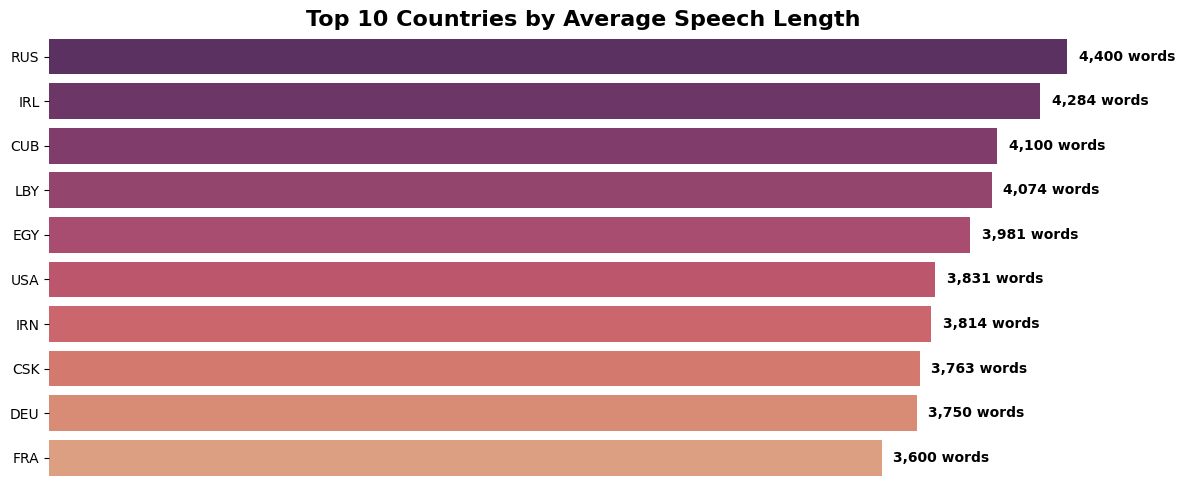

In [393]:
# --Top10 countries with highest average speech length
avg_len = (df.groupby('country')['word_count']
           .mean()
           .sort_values(ascending=False)
           .head(10)
           .reset_index())

plt.figure(figsize=(12, 5))
plot = sns.barplot(data=avg_len,
                   x='word_count',
                   y='country',
                   palette="flare_r")

for i, p in enumerate(plot.patches):
    width = p.get_width()
    plot.text(width + 50, p.get_y() + p.get_height()/2, 
              f'{int(width):,} words', va='center',fontweight='bold')

sns.despine(left=True, bottom=True)
plt.title("Top 10 Countries by Average Speech Length", fontsize=16, fontweight='bold')
plot.set_xticks([])
plot.set_xlabel('')
plot.set_ylabel('')

plt.tight_layout()
plt.show()

C:\Users\Nico\AppData\Local\Temp\ipykernel_9796\1750413530.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=top_climate, x='norm', y='country', palette="Greens_r")


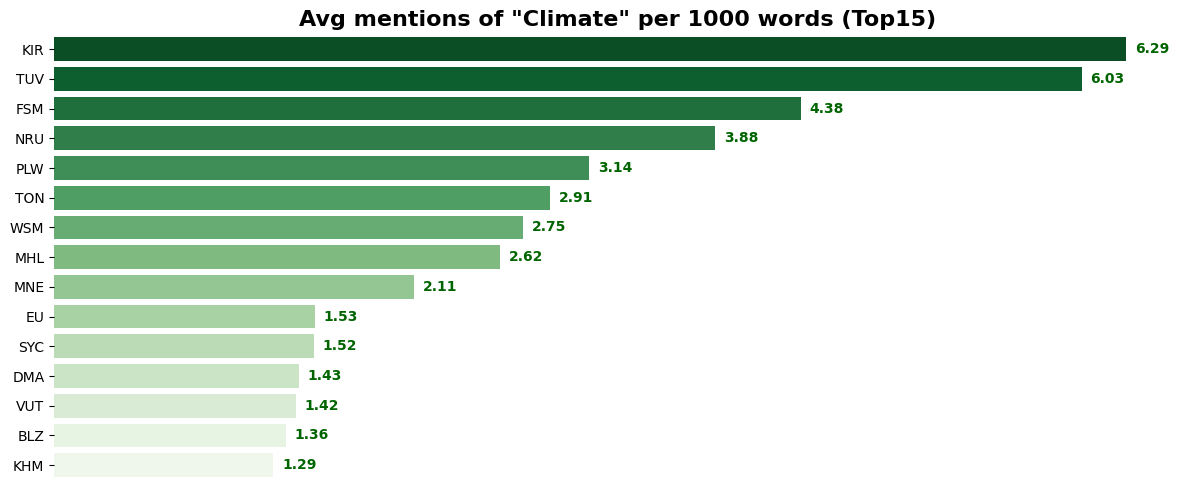

In [394]:
top_climate = (df.assign(
    norm = df['text'].str.lower().str.count('climate') / (df['word_count'] / 1000))
    .groupby('country')['norm'].mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index())


plt.figure(figsize=(12, 5))

plot = sns.barplot(data=top_climate, x='norm', y='country', palette="Greens_r")

for p in plot.patches:
    val = p.get_width()
    plot.text(val + 0.05, p.get_y() + p.get_height()/2, f'{val:.2f}', va='center', fontweight='bold', color='darkgreen')

sns.despine(left=True, bottom=True)
plot.set(xticks=[], xlabel='', ylabel='')

plt.title("Avg mentions of \"Climate\" per 1000 words (Top15)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\Nico\AppData\Local\Temp\ipykernel_9796\3423184333.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=top_ref, x='norm', y='country', palette="flare")


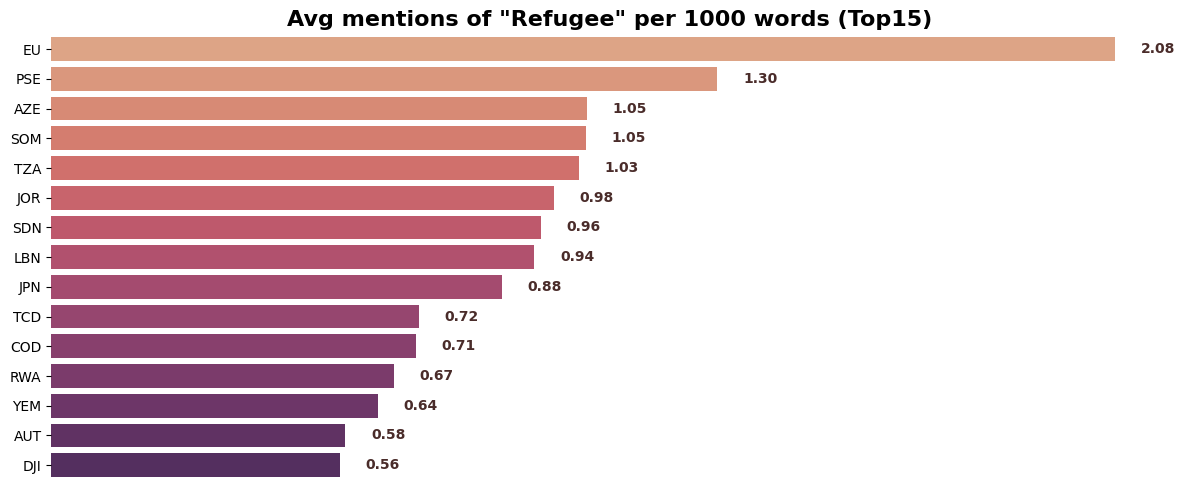

In [395]:
top_ref = (df.assign(
    norm = df['text'].str.lower().str.count(r'\brefugee\w*\b') / (df['word_count'] / 1000))
    .groupby('country')['norm'].mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index())


plt.figure(figsize=(12, 5))

plot = sns.barplot(data=top_ref, x='norm', y='country', palette="flare")

for p in plot.patches:
    val = p.get_width()
    plot.text(val + 0.05, p.get_y() + p.get_height()/2, f'{val:.2f}', va='center', fontweight='bold', color='#4a2c2a')

sns.despine(left=True, bottom=True)
plot.set(xticks=[], xlabel='', ylabel='')

plt.title("Avg mentions of \"Refugee\" per 1000 words (Top15)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()




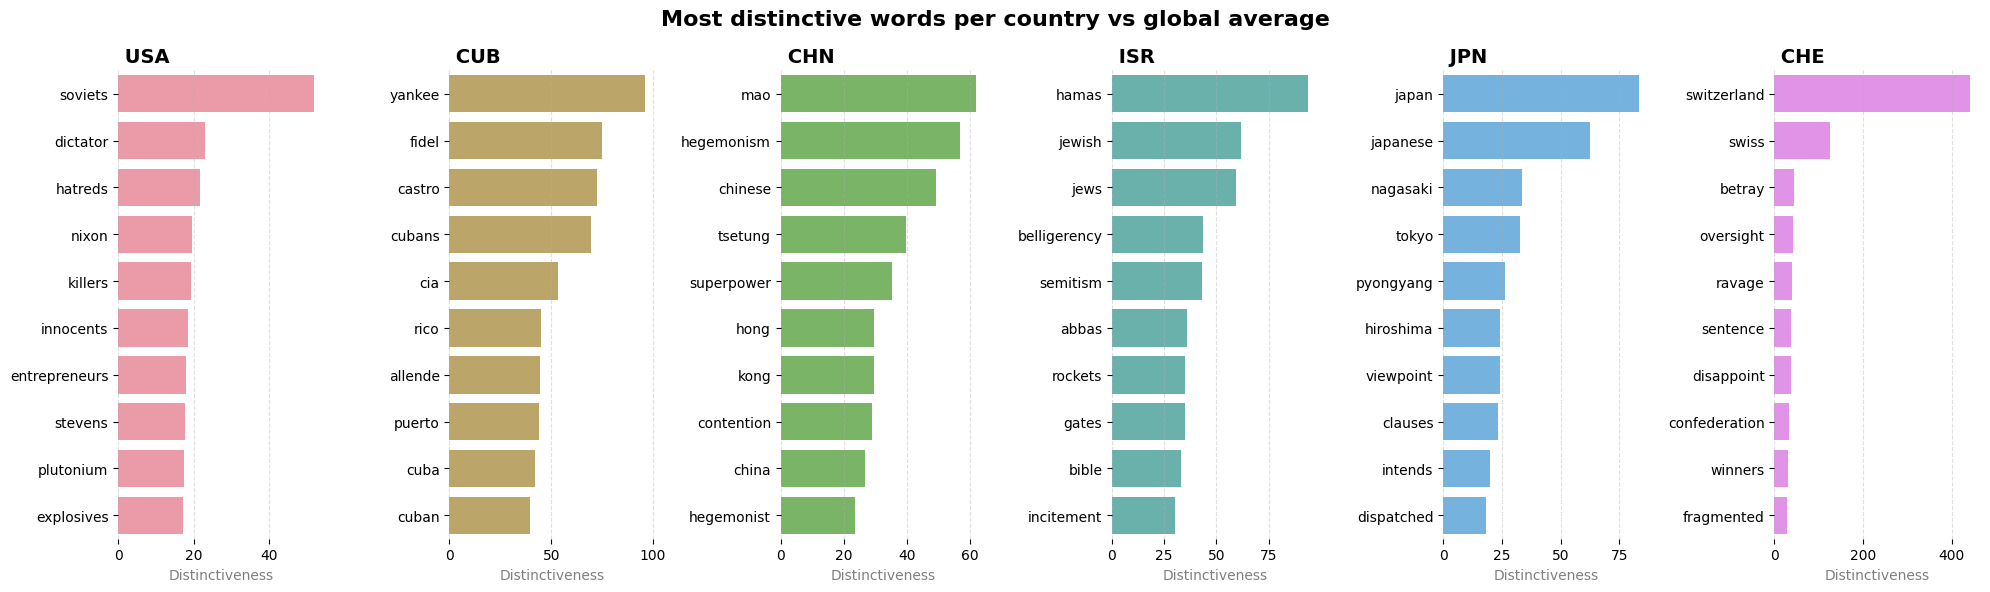

In [396]:
# --Words disproportionately used by one country vs everyone else

all_words = df['tokens'].explode()
global_counts = all_words.value_counts()
total_global_words = len(all_words)

def get_signature_words(country_code):
    country_words = df[df['country'] == country_code]['tokens'].explode()
    country_counts = country_words.value_counts()
    
    # Calculate Ratio = (Country Freq %) / (Global Freq %)
    # We only look at words that appear >= 50 times globally to avoid noise
    common_words = global_counts[global_counts >= 50].index
    
    ratios = []
    for word in common_words:
        if word in country_counts:
            country_pct = country_counts[word] / len(country_words)
            global_pct = global_counts[word] / total_global_words
            ratios.append({'word': word, 'ratio': country_pct / global_pct})
    return pd.DataFrame(ratios).sort_values('ratio', ascending=False).head(10)

focus_countries = ['USA', 'CUB', 'CHN', 'ISR', 'JPN', 'CHE']
fig, axes = plt.subplots(1, len(focus_countries), figsize=(20, 6), sharex=False)

colorr = sns.color_palette("husl", len(focus_countries))

for i, country in enumerate(focus_countries):
    data = get_signature_words(country)
    ax = axes[i]
    
    sns.barplot(data=data, x='ratio', y='word', ax=ax, color=colorr[i], alpha=0.8)
    ax.set_title(f" {country}", fontweight='bold', fontsize=14, loc='left')
    ax.set_xlabel('Distinctiveness', alpha=0.5)
    ax.set_ylabel('')
    sns.despine(ax=ax, left=True, bottom=True)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle("Most distinctive words per country vs global average", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()